In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
image=cv2.imread('/content/images.png')

array([[[48, 48, 48],
        [20, 20, 20],
        [28, 28, 28],
        ...,
        [26, 26, 26],
        [25, 25, 25],
        [36, 36, 36]],

       [[48, 48, 48],
        [20, 20, 20],
        [28, 28, 28],
        ...,
        [26, 26, 26],
        [25, 25, 25],
        [36, 36, 36]],

       [[48, 48, 48],
        [20, 20, 20],
        [28, 28, 28],
        ...,
        [26, 26, 26],
        [25, 25, 25],
        [36, 36, 36]],

       ...,

       [[48, 48, 48],
        [25, 25, 25],
        [28, 28, 28],
        ...,
        [28, 28, 28],
        [25, 25, 25],
        [36, 36, 36]],

       [[41, 41, 41],
        [16, 16, 16],
        [16, 16, 16],
        ...,
        [16, 16, 16],
        [16, 16, 16],
        [26, 26, 26]],

       [[69, 69, 69],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [69, 69, 69]]], dtype=uint8)
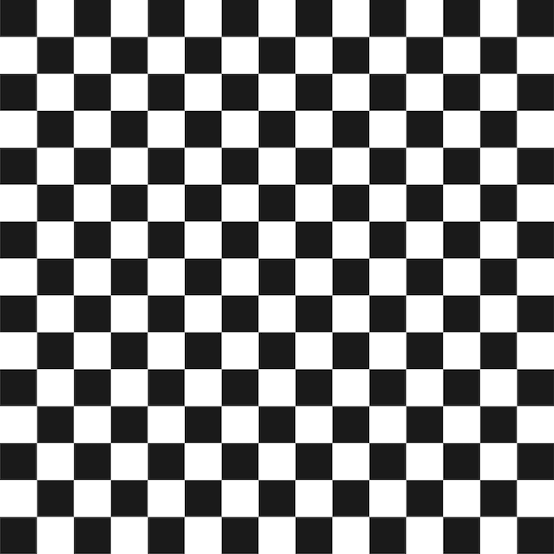

In [ ]:
image

In [ ]:
image.shape

(554, 554, 3)

In [ ]:
print(image)

[[[48 48 48]
  [20 20 20]
  [28 28 28]
  ...
  [26 26 26]
  [25 25 25]
  [36 36 36]]

 [[48 48 48]
  [20 20 20]
  [28 28 28]
  ...
  [26 26 26]
  [25 25 25]
  [36 36 36]]

 [[48 48 48]
  [20 20 20]
  [28 28 28]
  ...
  [26 26 26]
  [25 25 25]
  [36 36 36]]

 ...

 [[48 48 48]
  [25 25 25]
  [28 28 28]
  ...
  [28 28 28]
  [25 25 25]
  [36 36 36]]

 [[41 41 41]
  [16 16 16]
  [16 16 16]
  ...
  [16 16 16]
  [16 16 16]
  [26 26 26]]

 [[69 69 69]
  [60 60 60]
  [60 60 60]
  ...
  [60 60 60]
  [60 60 60]
  [69 69 69]]]


In [ ]:
# This is an rgb image. I will convert it to grey scale image.
gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
gray_image.shape

(554, 554)

In [ ]:
print(gray_image)

[[48 20 28 ... 26 25 36]
 [48 20 28 ... 26 25 36]
 [48 20 28 ... 26 25 36]
 ...
 [48 25 28 ... 28 25 36]
 [41 16 16 ... 16 16 26]
 [69 60 60 ... 60 60 69]]


In [ ]:
# Horizontal Edge detection from scratch
horizontal_kernel=np.array([[-1,-1,-1],
                            [0,0,0],
                            [1,1,1]])

k=horizontal_kernel.shape[0]
horizontal_kernel.shape

(3, 3)

In [ ]:
row,column=gray_image.shape
output=np.zeros((row-k+1,column-k+1))
output.shape

(552, 552)

In [ ]:
output

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
for i in range(1,row-1):
  for j in range(1,column-1):
    region=gray_image[i-1:i+2,j-1:j+2]
    output[i-1,j-1]=np.sum(region*horizontal_kernel)

In [ ]:
output

array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  5.,   7.,   4., ...,   6.,   4.,   2.],
       [-23., -26., -32., ..., -30., -29., -29.],
       [ 88.,  99.,  96., ...,  96.,  99., 100.]])

In [ ]:
print(output.min())
print(output.max())

-765.0
765.0


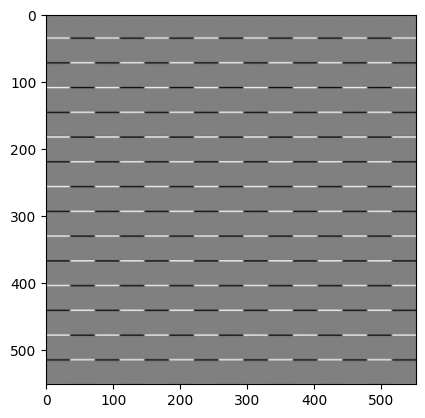

In [ ]:
plt.imshow(output,cmap='gray')

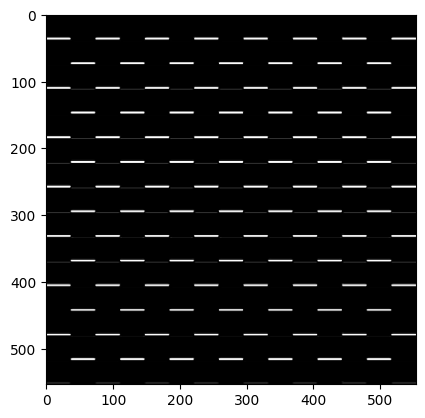

In [ ]:
# Horizontal edge detection using open cv
horizontal_edges = cv2.filter2D(gray_image, -1, horizontal_kernel)
plt.imshow(horizontal_edges,cmap='grey')

## Q1: Create a function to convert RGB to Grey scale image. Use numpy, pytorch, or tf but don't direct available functions.

Hint: Use the formula: Gray = 0.299*R + 0.587*G + 0.114*B for the conversion.


In [ ]:

import numpy as np

def rgb_to_grayscale_np(image):

    r_weight = 0.2989
    g_weight = 0.5870
    b_weight = 0.1140

    grayscale_image = (r_weight * image[:, :, 0] +
                       g_weight * image[:, :, 1] +
                       b_weight * image[:, :, 2])

    return grayscale_image


In [ ]:
r=rgb_to_grayscale_np(image)
r.shape

(554, 554)

## Q2 : Create a function to convolve_image taking image, kernel as input and returned convolved image.

Hint :  Easy Pesy - done in the class.  

In [ ]:
def convolve_image(image, kernel):

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            region = image[i:i + kernel_height, j:j + kernel_width]
            output[i, j] = np.sum(region * kernel)

    return output


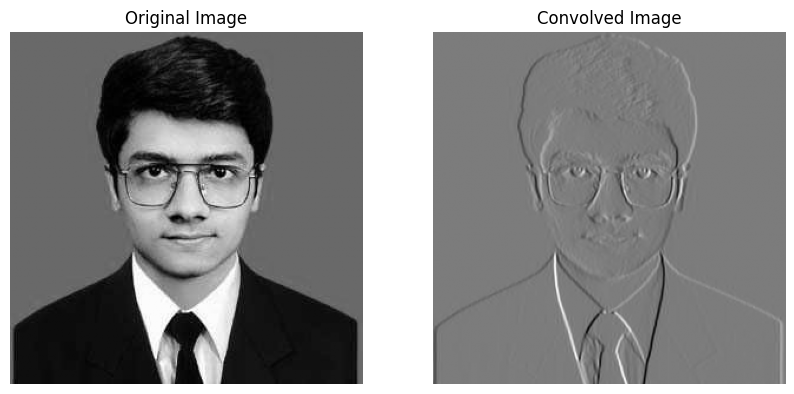

In [ ]:
image = cv2.imread('/content/photo.jpg', cv2.IMREAD_GRAYSCALE)

kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

convolved_image = convolve_image(image, kernel)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(convolved_image, cmap='gray')
plt.title("Convolved Image")
plt.axis("off")

plt.show()

## Q3 : Apply Below Kernels - Note the effects you observe

1. ```
[[0, 0, 0],
 [0, 1, 0],
 [0, 0, 0]]
```

2. ```
[[-1, -1, -1],
 [-1,  8, -1],
 [-1, -1, -1]]
 ```

3. ```
[[-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]]
```

4. ```
 [[-1, -2, -1],
 [0,  0,  0],
 [1,  2,  1]]
 ```


5. ```
 [[ 0, -1,  0],
 [-1,  5, -1],
 [ 0, -1,  0]]
 ```

6. ```
 [[-1, -1, -1],
 [-1,  8, -1],
 [-1, -1, -1]]
 ```
7. ```
[[-2, -1,  0],
 [-1,  1,  1],
 [ 0,  1,  2]]
```

8. ```
[[0.111,	0.111,	0.111]
[0.111,	0.111,	0.111]
[0.111,	0.111,	0.111]]
```

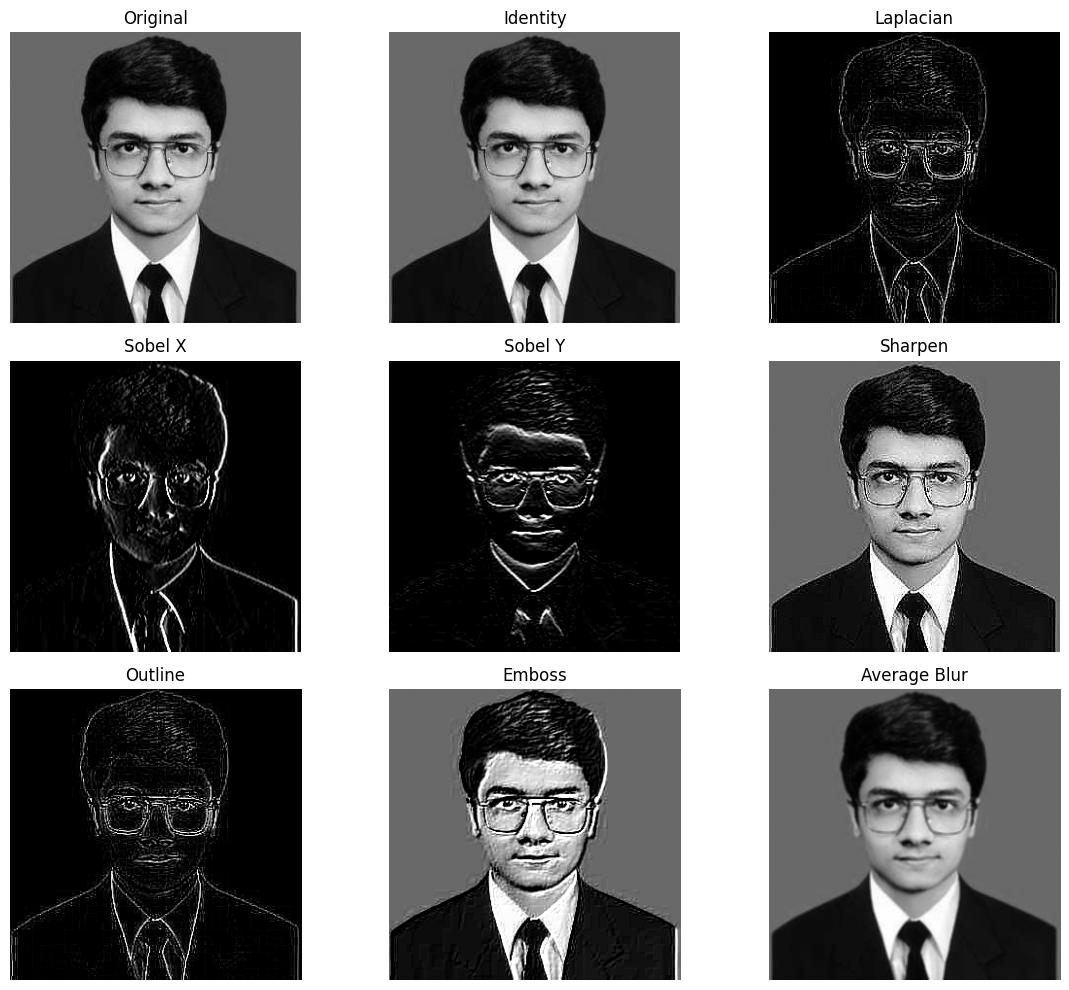

In [ ]:
kernels = {
    "Identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]]),

    "Laplacian": np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]]),

    "Sobel X": np.array([[-1, 0, 1],
                        [-2, 0, 2],
                         [-1, 0, 1]]),

    "Sobel Y": np.array([[-1, -2, -1],
                          [0, 0, 0],
                          [1, 2, 1]]),

    "Sharpen": np.array([[ 0, -1,  0],
                        [-1,  5, -1],
                         [ 0, -1,  0]]),

    "Outline": np.array([[-1, -1, -1],
                        [-1,  8, -1],
                         [-1, -1, -1]]),

    "Emboss": np.array([[-2, -1,  0],
                        [-1,  1,  1],
                        [ 0,  1,  2]]),

    "Average Blur": np.array([[0.111, 0.111, 0.111],
                              [0.111, 0.111, 0.111],
                               [0.111, 0.111, 0.111]])
}



plt.figure(figsize=(12, 10))
plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, (name, kernel) in enumerate(kernels.items(), start=2):
    filtered_image = cv2.filter2D(image, -1, kernel)
    plt.subplot(3, 3, i)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()
